In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("oil_prices_2426.csv")

print(df.head())
print(df.info())

         date  price (dollars)
0  21/09/2024            32.10
1  22/09/2024            32.25
2  23/09/2024            31.07
3  24/09/2024            31.50
4  25/09/2024            32.21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             500 non-null    object 
 1   price (dollars)  500 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.9+ KB
None


In [2]:
df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)
df = df.sort_index()

print(df.head())

            price (dollars)
date                       
2024-09-21            32.10
2024-09-22            32.25
2024-09-23            31.07
2024-09-24            31.50
2024-09-25            32.21


/tmp/ipykernel_3277/3322212904.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


In [3]:
print(df.isna().sum())

price (dollars)    0
dtype: int64


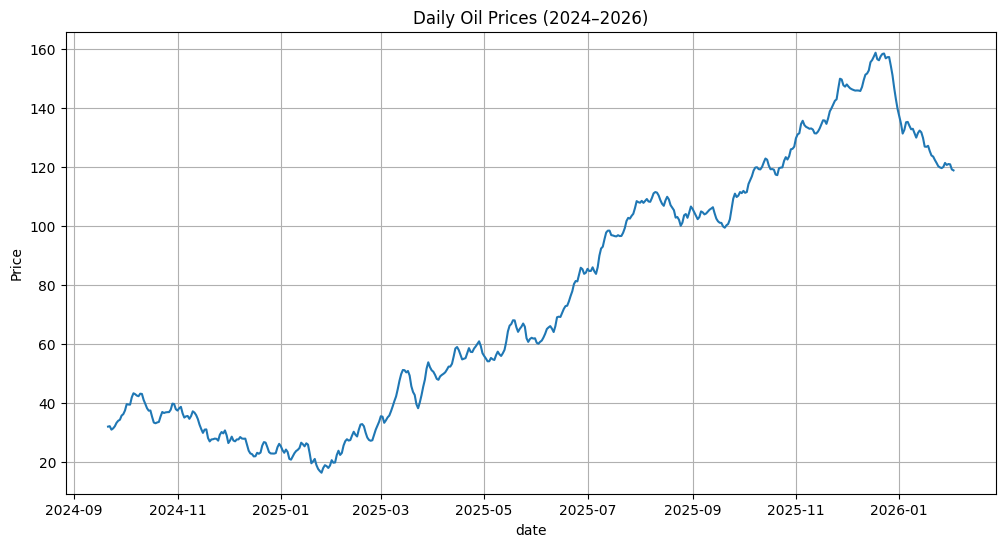

In [4]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['price (dollars)'])
plt.title("Daily Oil Prices (2024–2026)")
plt.xlabel("date")
plt.ylabel("Price")
plt.grid()
plt.show()

In [5]:
print(df['price (dollars)'].describe())

count    500.000000
mean      75.873980
std       42.912398
min       16.480000
25%       35.372500
50%       64.290000
75%      111.572500
max      158.780000
Name: price (dollars), dtype: float64


In [6]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error

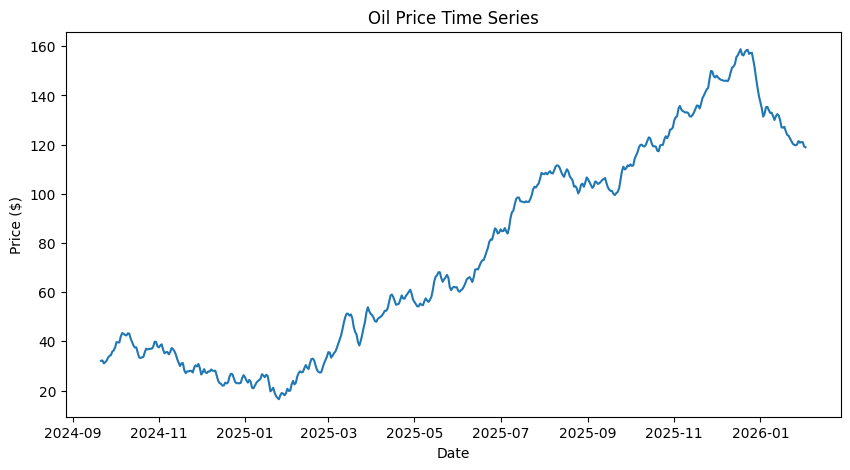

In [7]:
data = df['price (dollars)']

plt.figure(figsize=(10,5))
plt.plot(data)
plt.title("Oil Price Time Series")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.show()

In [8]:
result = adfuller(data)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] <= 0.05:
    print("Series is stationary")
else:
    print("Series is NOT stationary")

ADF Statistic: -0.5462340182601634
p-value: 0.8826741397403068
Series is NOT stationary


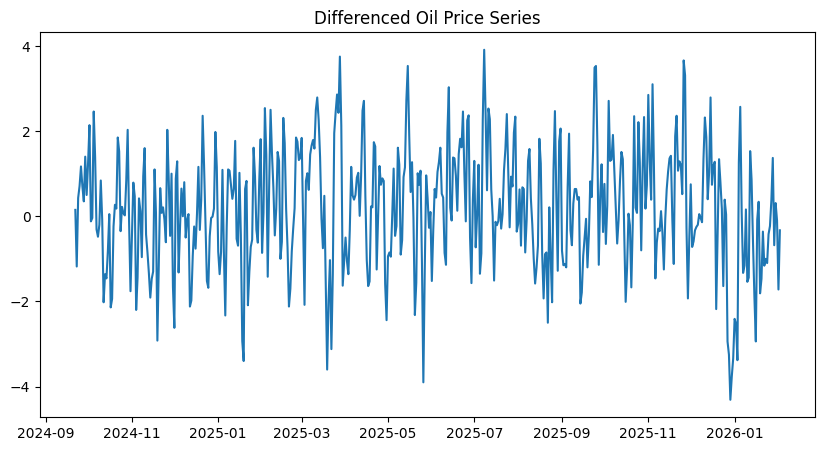

In [9]:
data_diff = data.diff().dropna()

plt.figure(figsize=(10,5))
plt.plot(data_diff)
plt.title("Differenced Oil Price Series")
plt.show()

<Figure size 1200x500 with 0 Axes>

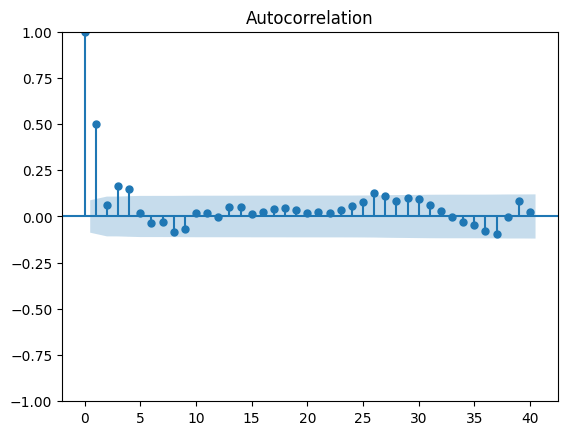

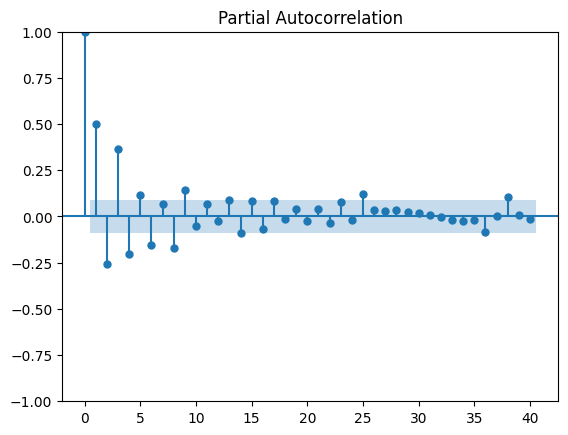

In [14]:
plt.figure(figsize=(12,5))

plot_acf(data_diff, lags=40)
plt.show()

plot_pacf(data_diff, lags=40)
plt.show()

In [15]:
train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]

In [16]:
arima_model = ARIMA(train, order=(2,1,2))

arima_model_fit = arima_model.fit()

print(arima_model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:        price (dollars)   No. Observations:                  400
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -561.681
Date:                Sun, 08 Mar 2026   AIC                           1133.362
Time:                        19:55:44   BIC                           1153.307
Sample:                    09-21-2024   HQIC                          1141.261
                         - 10-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6828      0.883      0.774      0.439      -1.047       2.413
ar.L2          0.0150      0.069      0.219      0.826      -0.119       0.149
ma.L1          0.2875      0.878      0.327      0.7

In [17]:
predictions = arima_model_fit.forecast(steps=len(test))

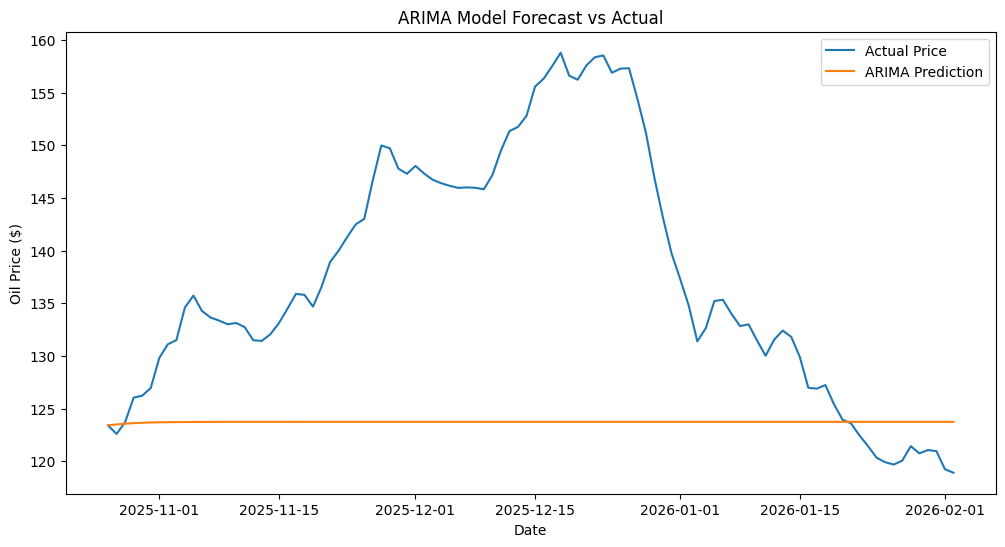

In [18]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label="Actual Price")
plt.plot(test.index, predictions, label="ARIMA Prediction")

plt.title("ARIMA Model Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Oil Price ($)")
plt.legend()

plt.show()

In [19]:
mae = mean_absolute_error(test, predictions)

rmse = np.sqrt(mean_squared_error(test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 14.572486526233384
RMSE: 18.047123733676408


In [20]:
future_steps = 730

forecast_result = arima_model_fit.get_forecast(steps=future_steps)

forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

In [21]:
future_dates = pd.date_range(
    start=data.index[-1],
    periods=future_steps+1,
    freq='D'
)[1:]

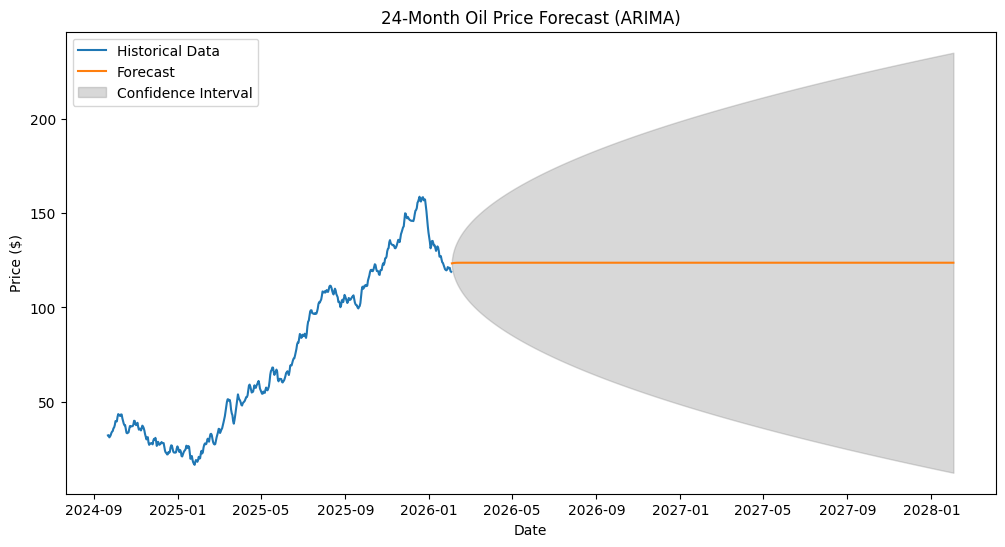

In [22]:
plt.figure(figsize=(12,6))

plt.plot(data.index, data, label="Historical Data")

plt.plot(future_dates, forecast, label="Forecast")

plt.fill_between(
    future_dates,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    color='gray',
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("24-Month Oil Price Forecast (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()

plt.show()

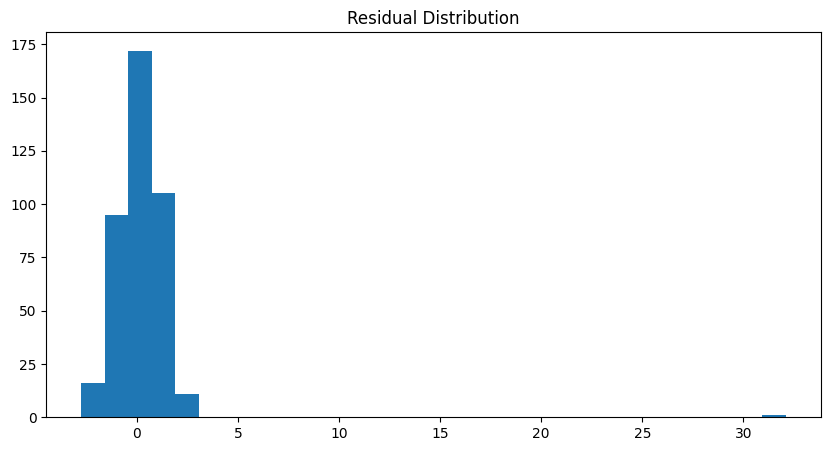

In [23]:
residuals = arima_model_fit.resid

plt.figure(figsize=(10,5))
plt.hist(residuals, bins=30)

plt.title("Residual Distribution")
plt.show()

LSTM MODEL


In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [11]:
data = df[['price (dollars)']]
data.head()

,price (dollars)
date,
2024-09-21,32.10
2024-09-22,32.25
2024-09-23,31.07
2024-09-24,31.50
2024-09-25,32.21


In [26]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

In [27]:
window_size = 60

In [28]:
X = []
y = []

for i in range(window_size, len(scaled_data)):

    X.append(scaled_data[i-window_size:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (440, 60, 1)
y shape: (440, 1)


In [30]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [31]:
lstm_model = Sequential()

lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
lstm_model.add(LSTM(units=50))

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test)
)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - loss: 0.1425 - val_loss: 0.0228
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0119 - val_loss: 0.0371
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0055 - val_loss: 0.0078
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0024 - val_loss: 0.0038
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0013 - val_loss: 0.0053
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0011 - val_loss: 0.0035
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0010 - val_loss: 0.0034
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 9.6260e-04 - val_loss: 0.0035
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0011 - val_loss: 0.0031
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0010 - val_loss: 0.0030
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0010 - val_loss: 0.0032
Epoch 12/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss

In [33]:
predictions = lstm_model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step


In [34]:
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

mape = np.mean(np.abs((y_test_actual - predictions)/y_test_actual))*100

print("MAE:",mae)
print("RMSE:",rmse)
print("MAPE:",mape)

MAE: 6.409210544932972
RMSE: 7.2258704909644305
MAPE: 4.5894463562037275


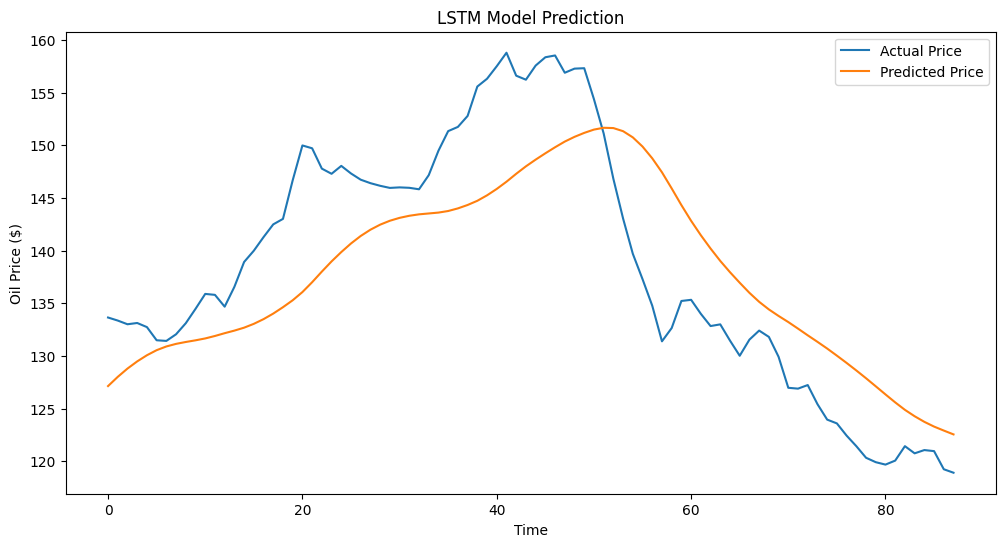

In [35]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")

plt.title("LSTM Model Prediction")
plt.xlabel("Time")
plt.ylabel("Oil Price ($)")
plt.legend()

plt.show()

In [36]:
forecast_steps = 730

last_sequence = scaled_data[-window_size:]

future_forecast = []
current_sequence = last_sequence.copy()

for i in range(forecast_steps):

    pred = lstm_model.predict(current_sequence.reshape(1,window_size,1))

    future_forecast.append(pred[0,0])

    current_sequence = np.append(current_sequence[1:], pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━

In [37]:
future_forecast = np.array(future_forecast).reshape(-1,1)

future_forecast = scaler.inverse_transform(future_forecast)

In [38]:
future_dates = pd.date_range(
    start=df.index[-1],
    periods=forecast_steps+1,
    freq='D'
)[1:]

In [39]:
forecast_values = future_forecast.flatten()

lower_bound = forecast_values * 0.95
upper_bound = forecast_values * 1.05

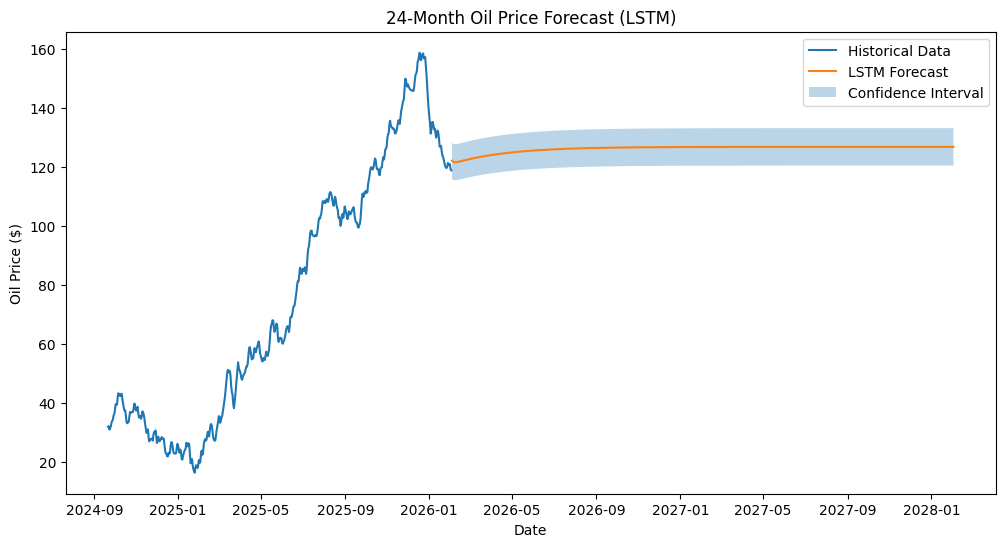

In [40]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['price (dollars)'], label="Historical Data")

plt.plot(future_dates, forecast_values, label="LSTM Forecast")

plt.fill_between(
    future_dates,
    lower_bound,
    upper_bound,
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("24-Month Oil Price Forecast (LSTM)")
plt.xlabel("Date")
plt.ylabel("Oil Price ($)")
plt.legend()

plt.show()